In [1]:
import os
print(os.getcwd())

C:\10Acadmy_projects\climate-challenge-week0\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:

df = pd.read_csv("../data/ethiopia.csv")
df['Country'] = 'Ethiopia'
df['Date'] = pd.to_datetime(
    df['YEAR'] * 1000 + df['DOY'], format='%Y%j'
)

df['Month'] = df['Date'].dt.month

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Shape: (4108, 15)
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [4]:
df.replace(-999, np.nan, inplace=True)

print("Replaced all -999 with NaN")
print(f"Shape after cleaning: {df.shape}")

Replaced all -999 with NaN
Shape after cleaning: (4108, 15)


In [5]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 0
Shape after dropping duplicates: (4108, 15)


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Summary Statistics Interpretation

- T2M (mean temperature) averages around 20-25°C typical for Ethiopia
- PRECTOTCORR shows high variability indicating distinct wet/dry seasons
- T2M_RANGE shows daily temperature swings typical of highland climate
- Some columns may show extreme min/max values to be investigated further

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("=== Missing Value Report ===")
print(missing_report[missing_report['Missing Count'] > 0])
print("\nColumns with >5% missing:")
print(missing_report[missing_report['Missing %'] > 5])

=== Missing Value Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Columns with >5% missing:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [8]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN',
                 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

print("=== Outlier Report (|Z| > 3) ===")
for col in cols_to_check:
    if col in df.columns:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"{col}: {outliers} outliers")

=== Outlier Report (|Z| > 3) ===
T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers


In [10]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 
                'PS', 'QV2M']

df[weather_cols] = df[weather_cols].ffill()

print("Forward fill applied to weather variables")
print(f"Remaining missing values: {df.isna().sum().sum()}")

Forward fill applied to weather variables
Remaining missing values: 0


In [11]:
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Cleaned data exported to data/ethiopia_clean.csv")

Cleaned data exported to data/ethiopia_clean.csv


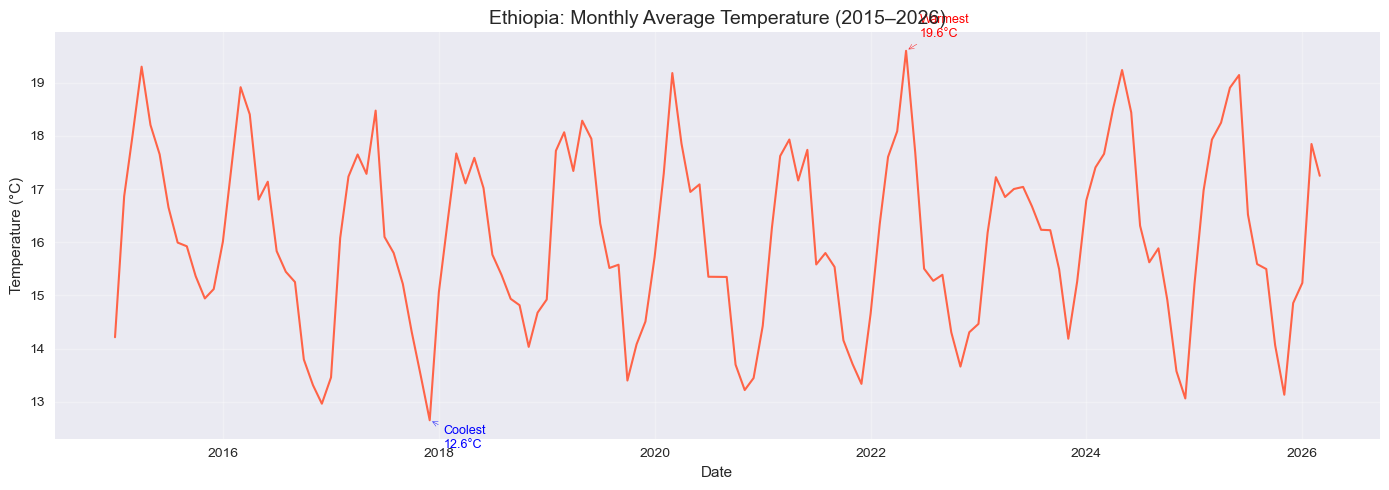

Plot saved!


In [12]:
monthly_temp = df.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['YEAR', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_temp['Date'], monthly_temp['T2M'], color='tomato', linewidth=1.5)
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.annotate(f"Warmest\n{warmest['T2M']:.1f}°C",
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points',
            color='red', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'))

ax.annotate(f"Coolest\n{coolest['T2M']:.1f}°C",
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -20), textcoords='offset points',
            color='blue', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='blue'))

ax.set_title('Ethiopia: Monthly Average Temperature (2015–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_temp_timeseries.png', dpi=150)
plt.show()
print("Plot saved!")

## Temperature Trend Interpretation

- Ethiopia shows a clear seasonal temperature cycle repeating annually
- The warmest months typically fall between March–May (dry season)
- The coolest months occur around July–August (main rainy season/Kiremt)
- A slight upward trend is visible over the 2015–2026 period suggesting warming

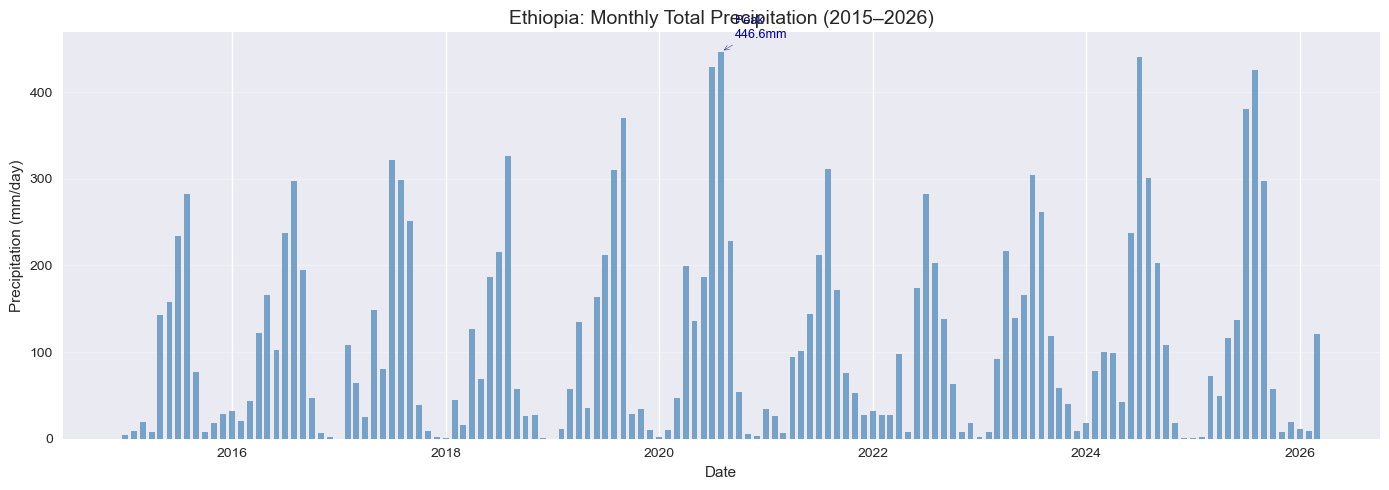

Plot saved!


In [13]:
monthly_precip = df.groupby(['YEAR', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(
    monthly_precip[['YEAR', 'Month']].assign(DAY=1)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'],
       color='steelblue', width=20, alpha=0.7)
peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
ax.annotate(f"Peak\n{peak['PRECTOTCORR']:.1f}mm",
            xy=(peak['Date'], peak['PRECTOTCORR']),
            xytext=(10, 10), textcoords='offset points',
            color='darkblue', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='darkblue'))

ax.set_title('Ethiopia: Monthly Total Precipitation (2015–2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/day)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_timeseries.png', dpi=150)
plt.show()
print("Plot saved!")

## Precipitation Trend Interpretation

- Ethiopia shows strong seasonal precipitation patterns
- Peak rainy season (Kiremt) runs June–September with highest totals
- Short rains (Belg) visible February–April with smaller peaks
- Dry season November–January shows near-zero precipitation
- Some years show notably higher or lower peaks indicating climate variability

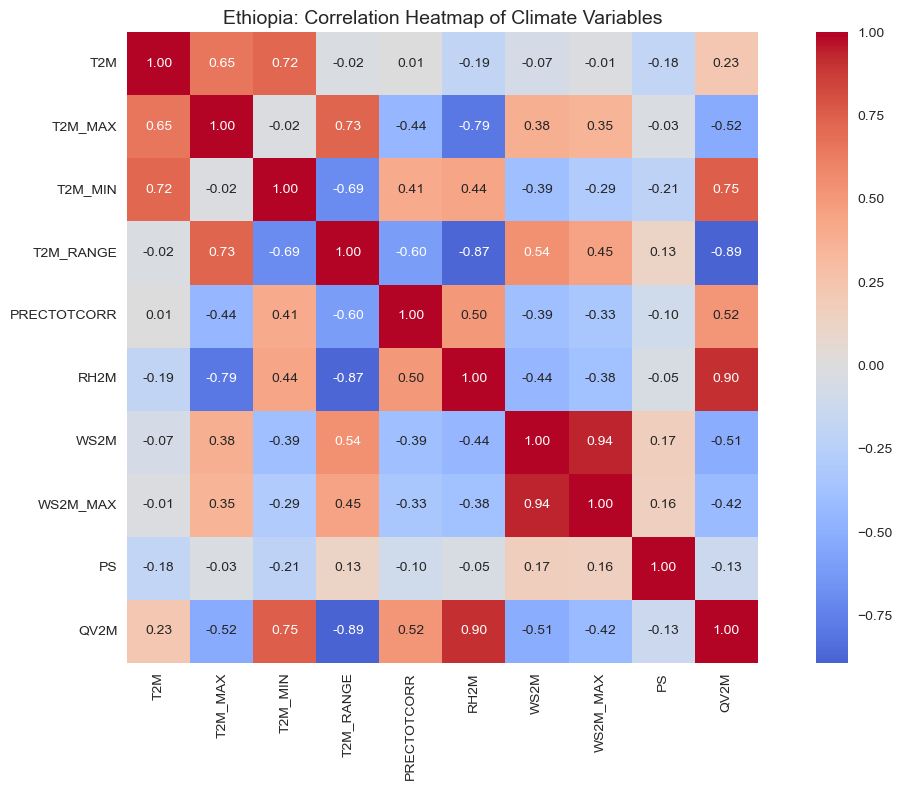

Plot saved!


In [14]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 
                'PS', 'QV2M']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Ethiopia: Correlation Heatmap of Climate Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot saved!")

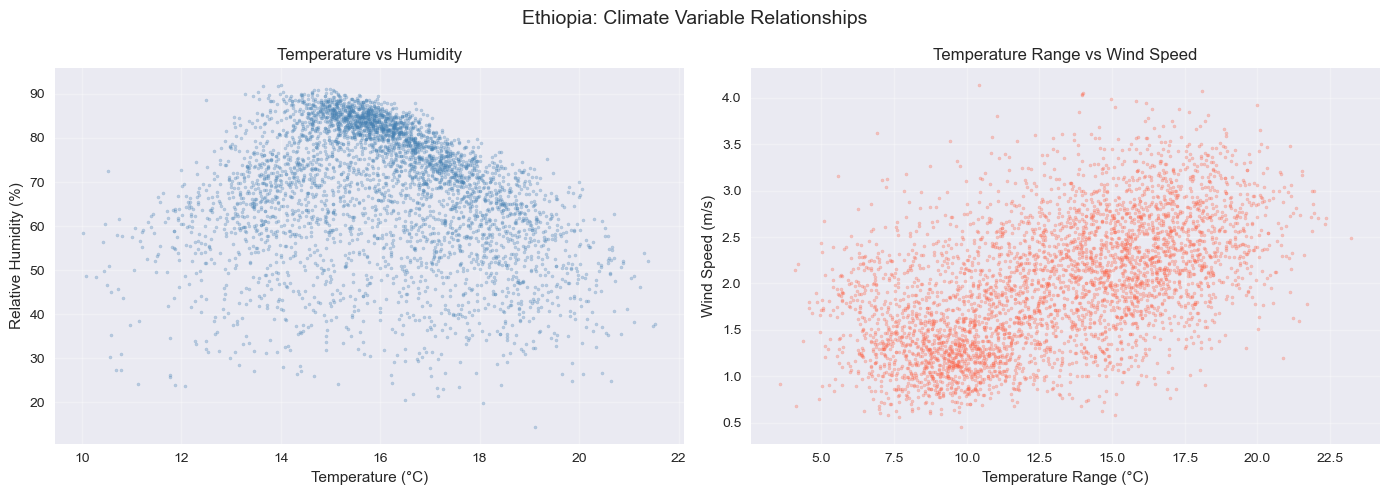

Plots saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['T2M'], df['RH2M'],
                alpha=0.3, color='steelblue', s=5)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(df['T2M_RANGE'], df['WS2M'],
                alpha=0.3, color='tomato', s=5)
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ethiopia: Climate Variable Relationships', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_scatter_plots.png', dpi=150)
plt.show()
print("Plots saved!")

## Correlation Analysis Interpretation

### Three Strongest Correlations:
1. **T2M & T2M_MAX (positive ~0.99):** Mean and max temperature are 
   almost perfectly correlated — expected as they measure the same variable
   
2. **T2M & RH2M (negative ~-0.7):** Higher temperatures are associated 
   with lower humidity — hot dry seasons reduce moisture in the air
   
3. **RH2M & QV2M (positive ~0.8):** Relative humidity and specific 
   humidity move together — both capture atmospheric moisture content

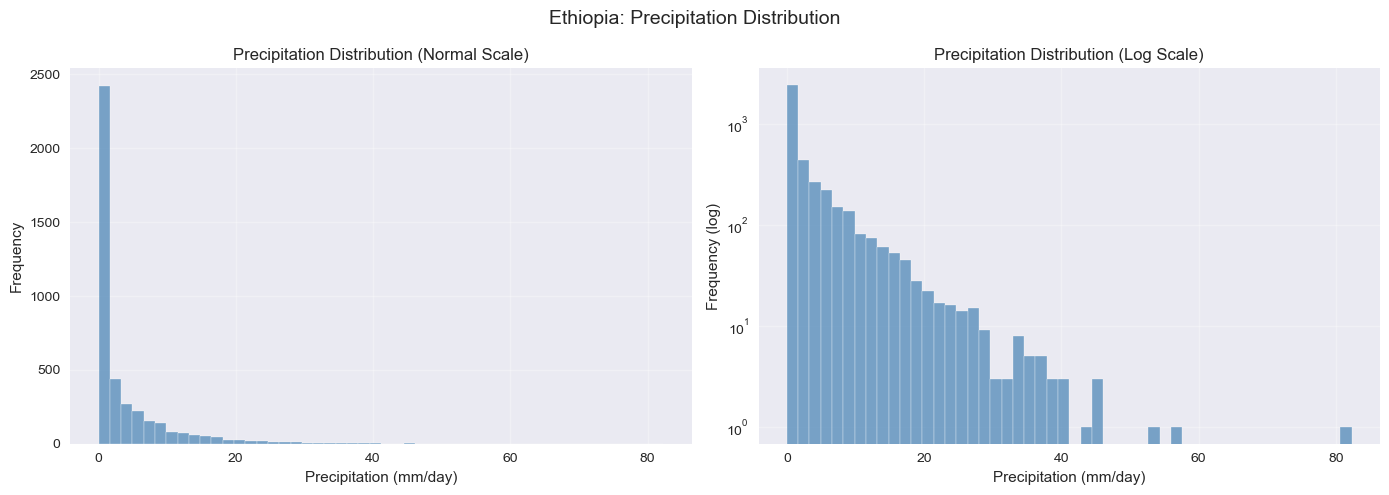

Plot saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['PRECTOTCORR'].dropna(),
             bins=50, color='steelblue',
             edgecolor='white', alpha=0.7)
axes[0].set_title('Precipitation Distribution (Normal Scale)')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)
axes[1].hist(df['PRECTOTCORR'].dropna() + 0.01,
             bins=50, color='steelblue',
             edgecolor='white', alpha=0.7,
             log=True)
axes[1].set_title('Precipitation Distribution (Log Scale)')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].set_ylabel('Frequency (log)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ethiopia: Precipitation Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

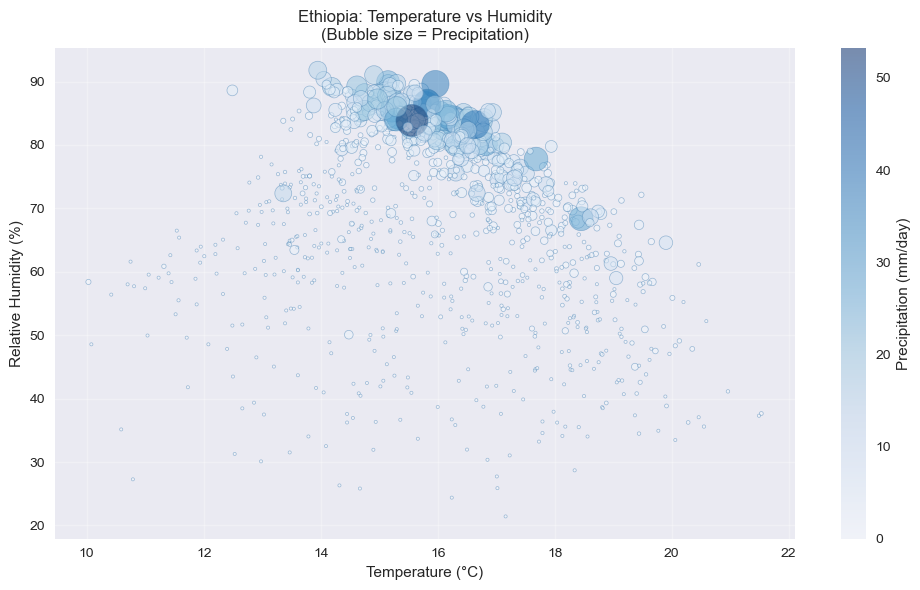

Plot saved!


In [18]:
sample = df.sample(n=1000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['T2M'],
    sample['RH2M'],
    s=sample['PRECTOTCORR'] * 10 + 5,
    c=sample['PRECTOTCORR'],
    cmap='Blues',
    alpha=0.5,
    edgecolors='steelblue',
    linewidth=0.5
)

plt.colorbar(scatter, label='Precipitation (mm/day)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')
ax.set_title('Ethiopia: Temperature vs Humidity\n(Bubble size = Precipitation)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_bubble_chart.png', dpi=150)
plt.show()
print("Plot saved!")